# Actual Analysis of Data 

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')



In [6]:
print('hello')
warnings.filterwarnings('ignore') # this is how you can ignore all the warning in your code there are not the errors but just the warnings 
warnings.warn('this is not to be done')# and this is how you can give an explicit user warning 

hello


In [7]:
# Loading the dataset 

# creating connection
conn=sqlite3.connect('inventory.db')

# fetching the vendor summary data 
df=pd.read_sql_query('select * from vendor_sales_summary',conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


## Exploratory Data Analysis
* Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be
included in the final analysis.
* In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns,
identify anomalies, and ensure data quality before proceeding with further analysis.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollar,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


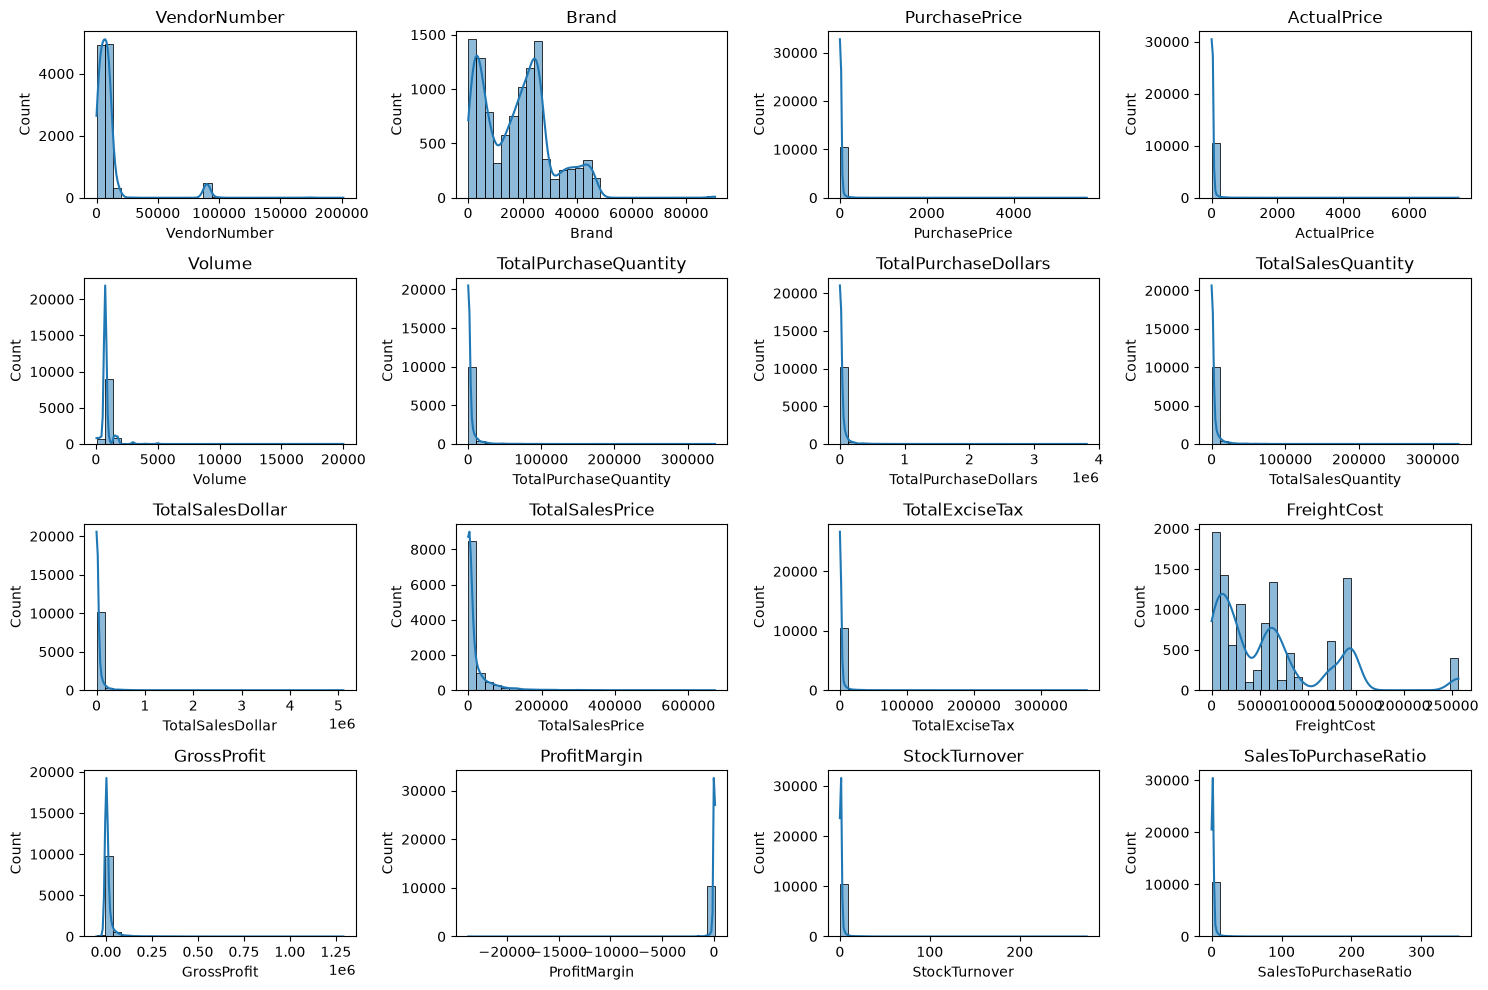

In [9]:
numeric_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()



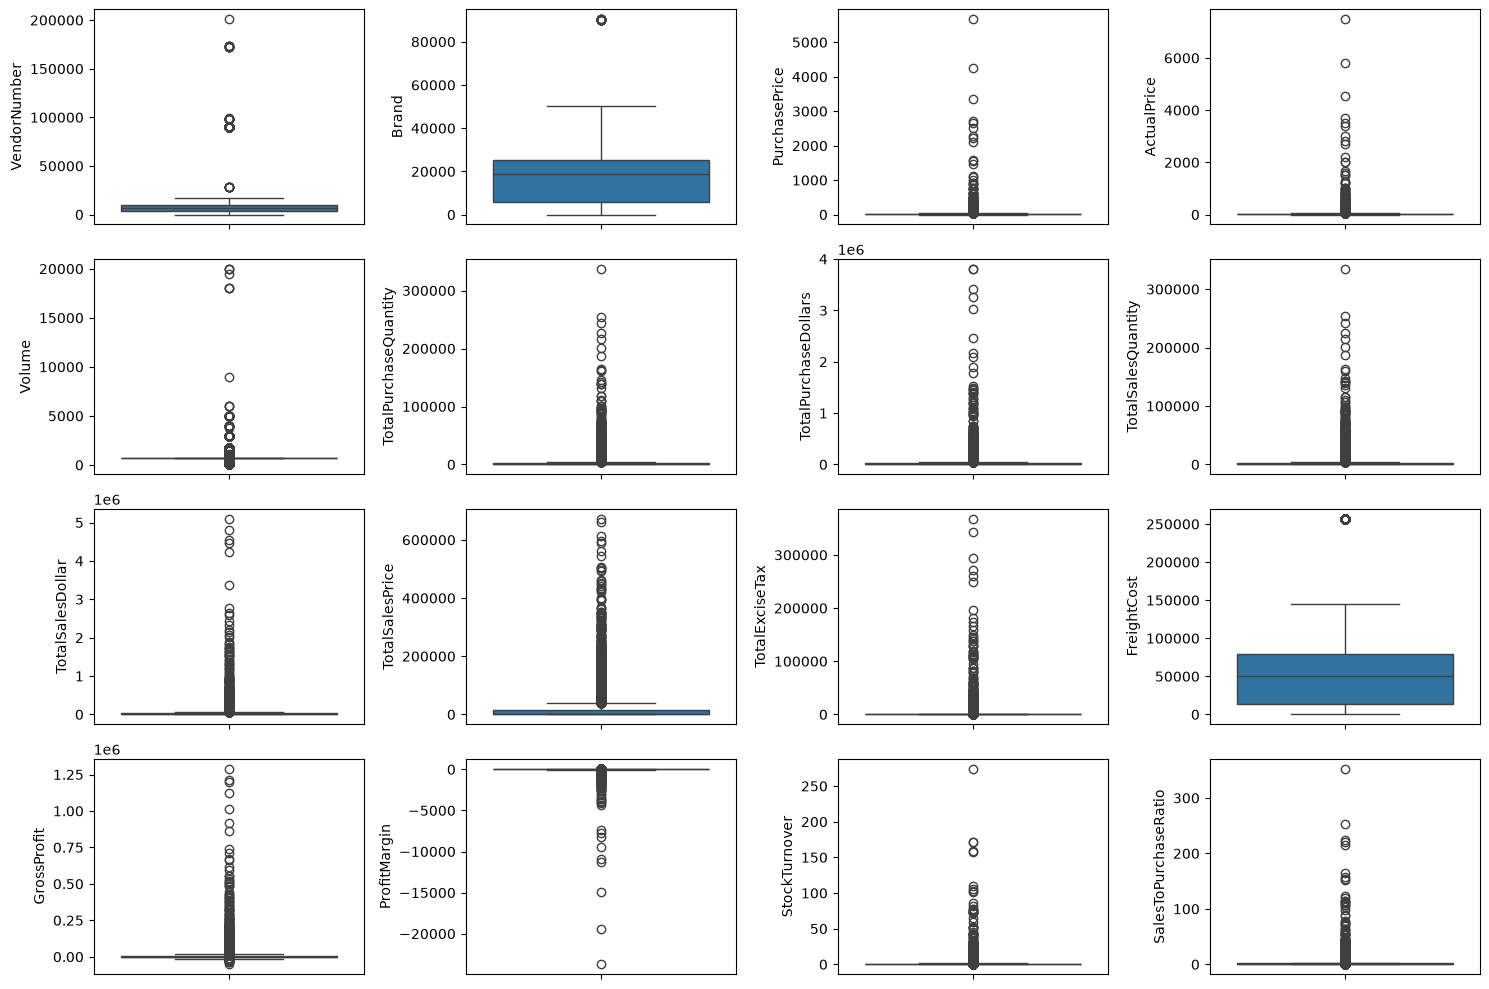

In [10]:
# Outlier detection with Boxplot
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

## Summary Statistics Insights:
**Negative & Zero Values:**
* Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price ..
* Profit Margin: Has a minimum of -oo, which suggests cases where revenue is zero or even lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete
stock.

**Outliers Indicated by High Standard Deviations:**
* Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium
products.
* Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [11]:
# now filter the data by removing inconsistency 
df=pd.read_sql_query(""" select * 
FROM vendor_sales_summary
WHERE GrossProfit> 0
AND ProfitMargin > 0
And TotalSalesQuantity >0""",conn)

In [12]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


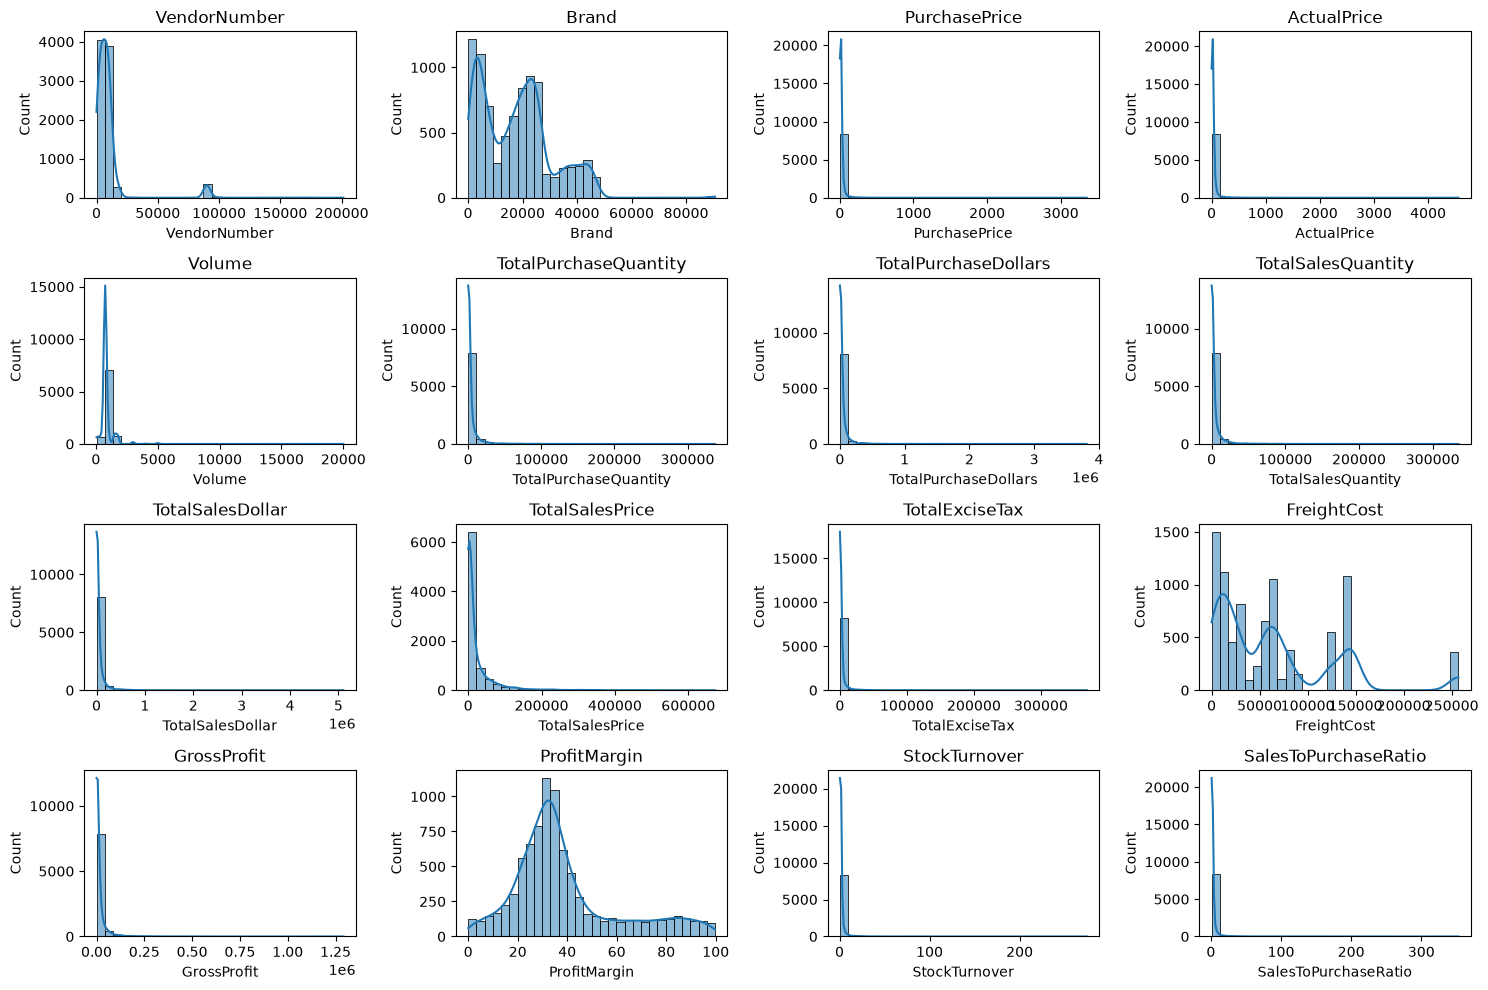

In [13]:
numeric_cols=df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


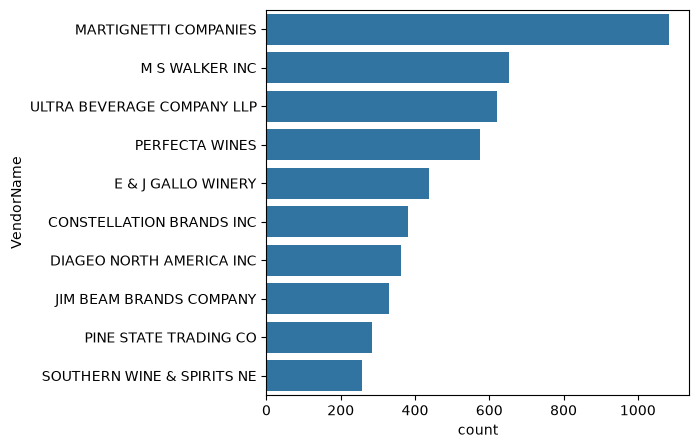

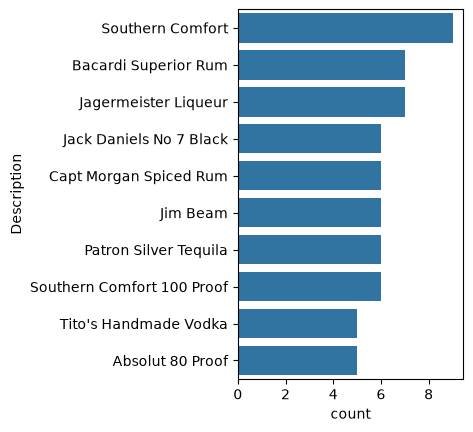

In [14]:
#Count Plots for categorical columns 

categorical_cols=['VendorName','Description']

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order= df[col].value_counts().index[:10])
    plt.tight_layout
    plt.show()

    # this will give us the distribution of the product name and vendor name 


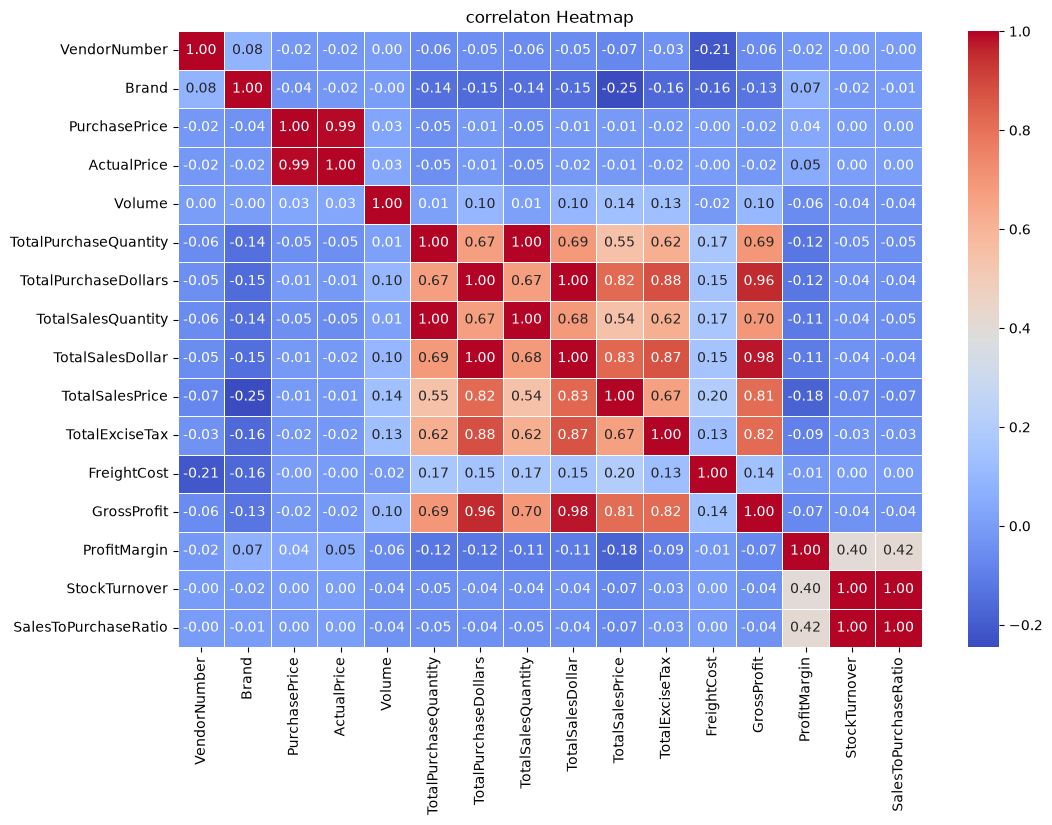

In [15]:
# correlation heatmap 
# to see the crrelation between two numerical  variables 

plt.figure(figsize=(12,8))
correlation_matrix=df[numeric_cols].corr()
sns.heatmap(correlation_matrix,annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('correlaton Heatmap')
plt.show()

## Correlation Insights 
* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact
sales revenue or profit.
* Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
* Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
* StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

## DATA ANALYSIS
* identify brands that needs promotional or pricing adjustmensts which exhibits lower sales performance but higher profit margins.
 

In [16]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollar':'sum',
    'ProfitMargin':'mean'
}).reset_index()
brand_performance

,Description,TotalSalesDollar,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [17]:
low_sales_threshold= brand_performance['TotalSalesDollar'].quantile(0.15)
high_margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

'''
brand_performance['TotalSalesDollar']
brand_performance DataFrame mein se sirf TotalSalesDollar column select karo.

.quantile(0.15)
Aisi value find karo jiske neeche approximately 15% observations hain.

low_sales_threshold = brand_performance['TotalSalesDollar'].quantile(0.15)
Total sales ka 15th percentile find karo.


Dono lines ka business meaning
low_sales_threshold = brand_performance['TotalSalesDollar'].quantile(0.15)

➡️ Bottom 15% sales ko identify karne ke liye cutoff

high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

➡️ Top 15% profit margins ko identify karne ke liye cutoff

Ek line mein yaad rakh:

0.15 → bottom 15% ka cutoff

0.85 → top 15% ka cutoff
'''

"\nbrand_performance['TotalSalesDollar']\nbrand_performance DataFrame mein se sirf TotalSalesDollar column select karo.\n\n.quantile(0.15)\nAisi value find karo jiske neeche approximately 15% observations hain.\n\nlow_sales_threshold = brand_performance['TotalSalesDollar'].quantile(0.15)\nTotal sales ka 15th percentile find karo.\n\n\nDono lines ka business meaning\nlow_sales_threshold = brand_performance['TotalSalesDollar'].quantile(0.15)\n\n➡️ Bottom 15% sales ko identify karne ke liye cutoff\n\nhigh_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)\n\n➡️ Top 15% profit margins ko identify karne ke liye cutoff\n\nEk line mein yaad rakh:\n\n0.15 → bottom 15% ka cutoff\n\n0.85 → top 15% ka cutoff\n"

In [18]:
low_sales_threshold

np.float64(560.299)

In [19]:
high_margin_threshold

np.float64(64.97017552750111)

In [20]:
# filter brand with low sales but high profit margins 
target_brands= brand_performance[
    (brand_performance['TotalSalesDollar']<=low_sales_threshold)&
    (brand_performance['ProfitMargin']>=high_margin_threshold)
]
print('Brands with low sales but high Profit Margins: ')
display(target_brands.sort_values('TotalSalesDollar'))

'''
Brand performance table mein se woh brands nikalo jinki total sales bottom 15% mein hain AND jinka profit margin top 15% mein hai. Phir un brands ko sales ke lowest se highest order mein display karo.
'''

# from this querry we are egtting the brands whose sales is very low but the profit margin is very high

Brands with low sales but high Profit Margins: 


,Description,TotalSalesDollar,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


'\nBrand performance table mein se woh brands nikalo jinki total sales bottom 15% mein hain AND jinka profit margin top 15% mein hai. Phir un brands ko sales ke lowest se highest order mein display karo.\n'

In [21]:
brand_performance=brand_performance[brand_performance['TotalSalesDollar']<10000] # for better visualisation taking only data where total sales dollar is less than 10000

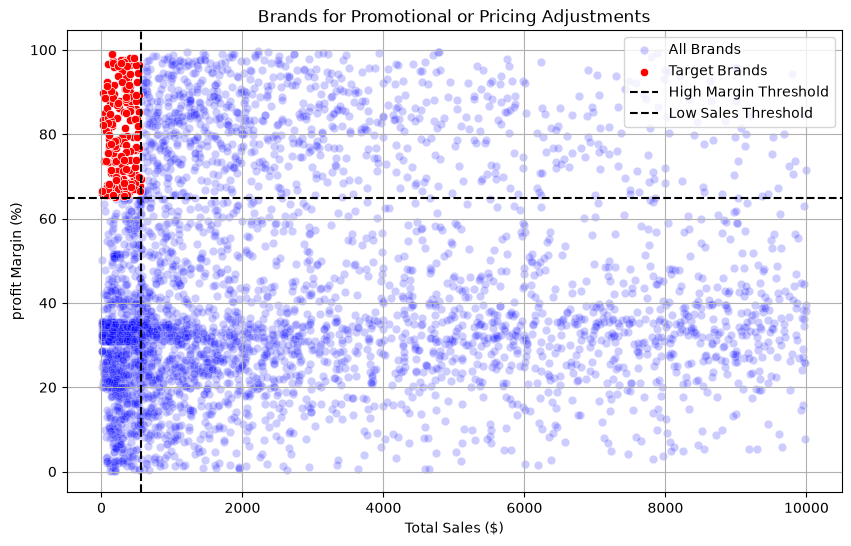

"\ndata=brand_performance\nMatlab graph ka data brand_performance DataFrame se lena hai.\n\nx='TotalSalesDollar'\nX-axis par:\nTotal Sales\naayegi.\n\ny='ProfitMargin'\nY-axis par:\nProfit Margin\naayega.\nJitna profit margin zyada → point utna upar.\n\nalpha=0.2\nYe transparency control karta hai.\nSo blue dots kaafi light/faded dikhenge.\nIska benefit ye hai ki jab hum target brands ko red mein highlight karenge, woh clearly visible honge.\n\n\nsecond scatterplot with red dots have only data which have low sales and high profit margin \n\n\naxhline = horizontal line\nYe ek horizontal line draw karega.\nhigh_margin_threshold par hogi.\nhigh_margin_threshold = ProfitMargin ka 85th percentile\nLine ke upar:\n➡️ High profit margin\nLine ke neeche:\n➡️ Lower profit margin\n\n\naxvline = vertical line.\nLine ke left:\n➡️ Low sales\nLine ke right:\n➡️ Higher sales\n\n\nplt.legend()\nLegend graph mein symbols ka meaning batata hai.\n\n\n\nplt.grid(True)\nGraph ke background mein grid lines a

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollar', y='ProfitMargin', color= "blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollar', y='ProfitMargin',color="red",label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--',color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle= '--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


'''
data=brand_performance
Matlab graph ka data brand_performance DataFrame se lena hai.

x='TotalSalesDollar'
X-axis par:
Total Sales
aayegi.

y='ProfitMargin'
Y-axis par:
Profit Margin
aayega.
Jitna profit margin zyada → point utna upar.

alpha=0.2
Ye transparency control karta hai.
So blue dots kaafi light/faded dikhenge.
Iska benefit ye hai ki jab hum target brands ko red mein highlight karenge, woh clearly visible honge.


second scatterplot with red dots have only data which have low sales and high profit margin 


axhline = horizontal line
Ye ek horizontal line draw karega.
high_margin_threshold par hogi.
high_margin_threshold = ProfitMargin ka 85th percentile
Line ke upar:
➡️ High profit margin
Line ke neeche:
➡️ Lower profit margin


axvline = vertical line.
Line ke left:
➡️ Low sales
Line ke right:
➡️ Higher sales


plt.legend()
Legend graph mein symbols ka meaning batata hai.



plt.grid(True)
Graph ke background mein grid lines add karta hai.

'''

## Second sales question 
* which vendor and brands demonstrate the highest sales performance?

In [23]:
# function for formatting 
def format_dollars(value):
    if value>= 1_00_00:
        return f'{value/1_000_000:.2f}M' # :.2f ye bolta hai number ko 2 decimal place tak show karo 
    elif value >=1_000:
        return f"{value/1_000:.2f}K"
    else: 
        return str(value)


format_dollars(1000000)

'1.00M'

In [24]:
# top vendors and brand by sales performance 
top_vendors= df.groupby('VendorName')['TotalSalesDollar'].sum().nlargest(10) # nlargest means top 10 
top_brands=df.groupby('Description')['TotalSalesDollar'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollar, dtype: float64

In [25]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollar, dtype: float64

In [26]:
# using lambda function to display our resultant output 
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollar, dtype: str

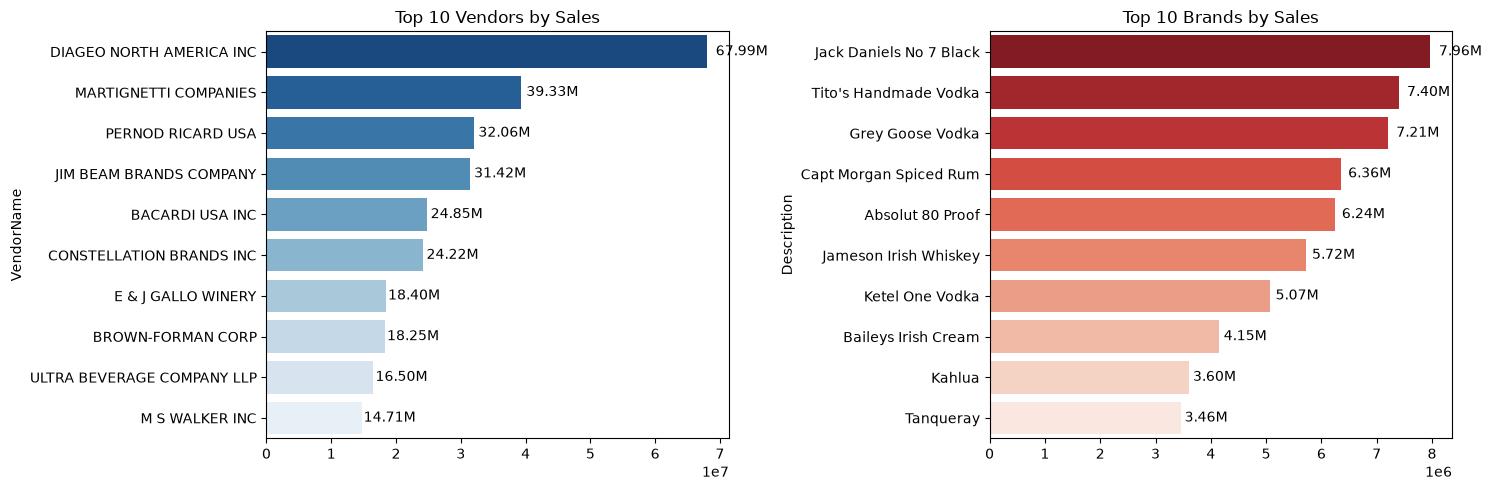

In [27]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

## Problem 3 
* which vendor contributes the most to total purchase dollars?

In [28]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollar':'sum'
}).reset_index()

In [29]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

# this querry finds the contribution of the vendors in total purchase 
# as vendor_performance['TotalPurchaseDollars'] this is the total purchase dollars of a single vendor which is divided by 
# vendor_performance['TotalPurchaseDollars'].sum() this 
# and this is the total sum of all the purchase dollars hence each vendor's data is divided by the total data of all the vendors 

In [30]:
vendor_performance.sort_values('PurchaseContribution%',ascending=False)
# as after this the values shown are not readable so we are doing roundof
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2) # til 2 decimal places 

In [31]:
# Display Top 10 Vendors 

# also the three columns of purchase, grossprofit and sales dollar have bad formatting so here also we can call out function format_dollars

top_vendors= vendor_performance.head(10) # this will display top 10 entries 
top_vendors['TotalSalesDollar']=top_vendors['TotalSalesDollar'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars) # here tis top_vendors only have the data of top 10 vendors stored
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollar,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [32]:
top_vendors['PurchaseContribution%'].sum()
# this will calculate the sum of total contribution of top 10 vendors 

np.float64(65.69000000000001)

In [33]:
# getting the cummulative sum value 
top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollar,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


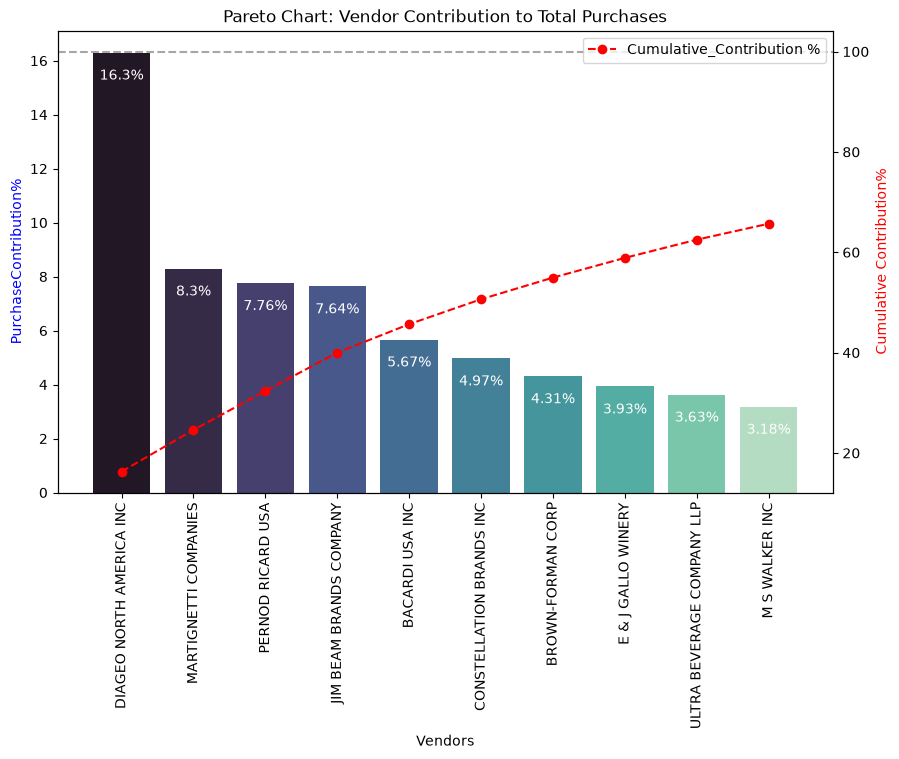

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value-1,
        str(value) + '%',
        ha='center',
        fontsize=10,
        color='white'
    )

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative_Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('PurchaseContribution%', color='blue')
ax2.set_ylabel('Cumulative Contribution%', color='red')
ax1.set_xlabel('Vendors')

ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')


# plt.tight_layout()
plt.show()

## Rroblem 3 
* how much of total procurement i dependent on the top vendors?


In [35]:
print(f'Total Purchase Contribution of top 10 vendors is {round(top_vendors["PurchaseContribution%"].sum(),2)}%')


Total Purchase Contribution of top 10 vendors is 65.69%


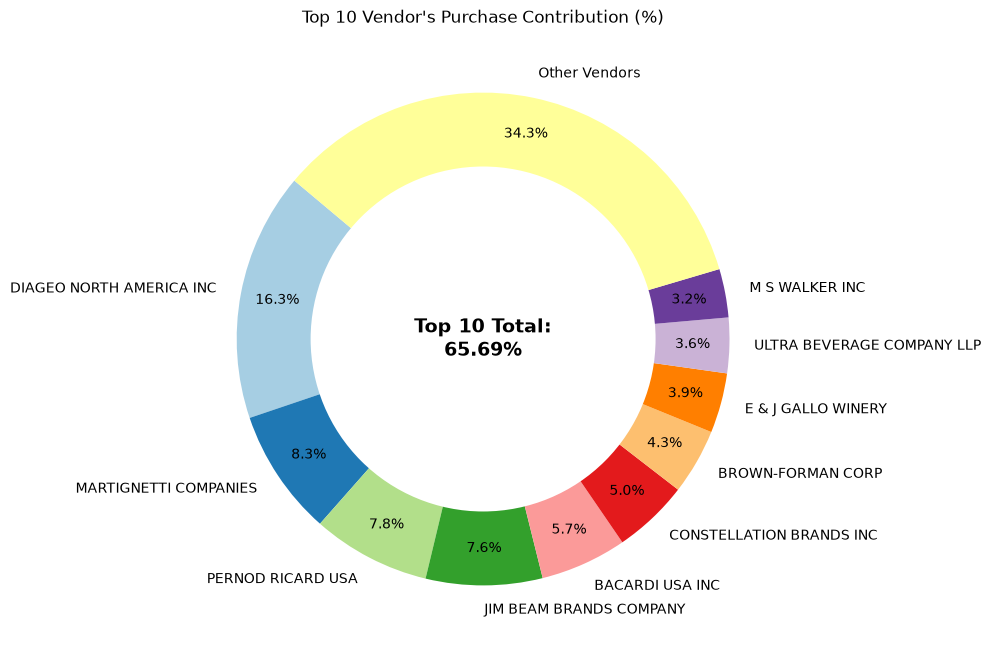

In [36]:
vendors=list(top_vendors['VendorName'].values)
purchase_contributions= list(top_vendors['PurchaseContribution%'].values)
total_contribution=sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


## problem 4 
* does purchasing in bul reduce the unit price, and what is the optimal purchase volume for cose savings?

In [37]:
# price of one single quantity 
# unit purchase price 
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']


In [38]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollar,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47


In [39]:
df['OrderSize']=pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['small','medium','large'])
# on the basis of quartiles the ordersize is divided into three equal bucket size 
# and it will store that in ordersize column 


In [40]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,large,145080
1,large,164038
2,large,187407
3,large,201682
4,large,138109
...,...,...
8560,small,2
8561,small,6
8562,small,2
8563,small,1


In [41]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,39.057543
medium,15.486414
large,10.777625


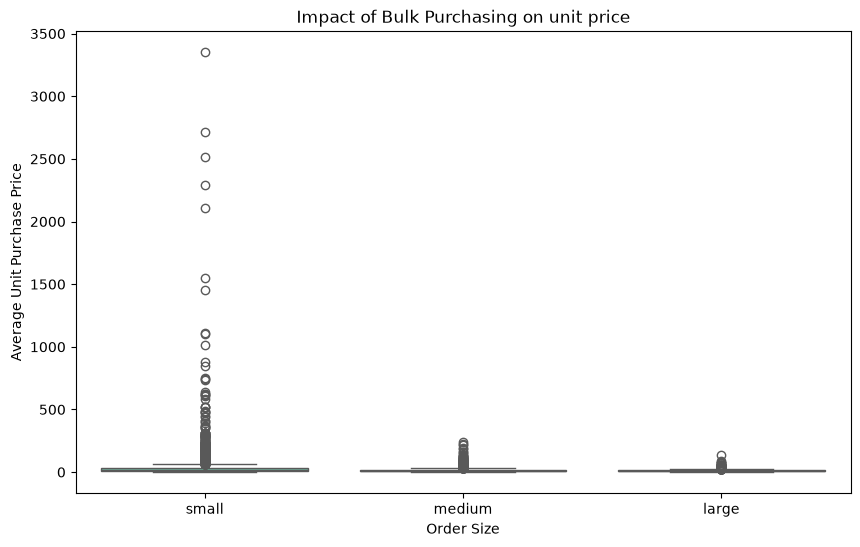

In [42]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title('Impact of Bulk Purchasing on unit price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

## Insights
* Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
* The price difference between Small and Large orders is substantial (~72% reduction in unit cost)
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue. 

## Problem 5
* which vendor have low inventory turnover, indicating excess stock and slow-moving products? 

In [43]:
# this means k uske pass stock zyada hai par vo shai se sell nahi kar pa rha hai  
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


## problem 6 
* How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [44]:
# now we have to find out ke kitna inventory sold ho chuka hai aur kitna aisa hai jo bacha hua hai yani k unsold hai uska kitna mmount bacha hua hai and konse aise vendors hai jo usme zyada contribute kar rahe hai 

In [47]:
df['UnsoldInventoruValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df['PurchasePrice']
print('Total unsold capital: ', format_dollars(df['UnsoldInventoruValue'].sum()))

Total unsold capital:  2.71M


In [49]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName") ["UnsoldInventoruValue"].sum().reset_index()

#Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoruValue", ascending=False)
inventory_value_per_vendor ['UnsoldInventoruValue'] = inventory_value_per_vendor ['UnsoldInventoruValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoruValue
25,DIAGEO NORTH AMERICA INC,0.72M
46,JIM BEAM BRANDS COMPANY,0.55M
68,PERNOD RICARD USA,0.47M
116,WILLIAM GRANT & SONS INC,0.40M
30,E & J GALLO WINERY,0.23M
79,SAZERAC CO INC,0.20M
11,BROWN-FORMAN CORP,0.18M
20,CONSTELLATION BRANDS INC,0.13M
61,MOET HENNESSY USA INC,0.13M
77,REMY COINTREAU USA INC,0.12M


## Problem 7 
* what is the 95% confidence intervals for profit margins of top-performing and low-performing vendors

In [52]:
# for top performing vendors 
top_threshold= df['TotalSalesDollar'].quantile(0.75)

# for low performing vendors 
low_threshold=df['TotalSalesDollar'].quantile(0.25)

In [ ]:
top_vendors=df[df["TotalSalesDollar"]>= top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollar"]>= low_threshold]["ProfitMargin"].dropna()



In [55]:
# to calculate the confidence interval


def confidence_interval(data,confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical*std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (37.29, 38.26), Mean: 37.77


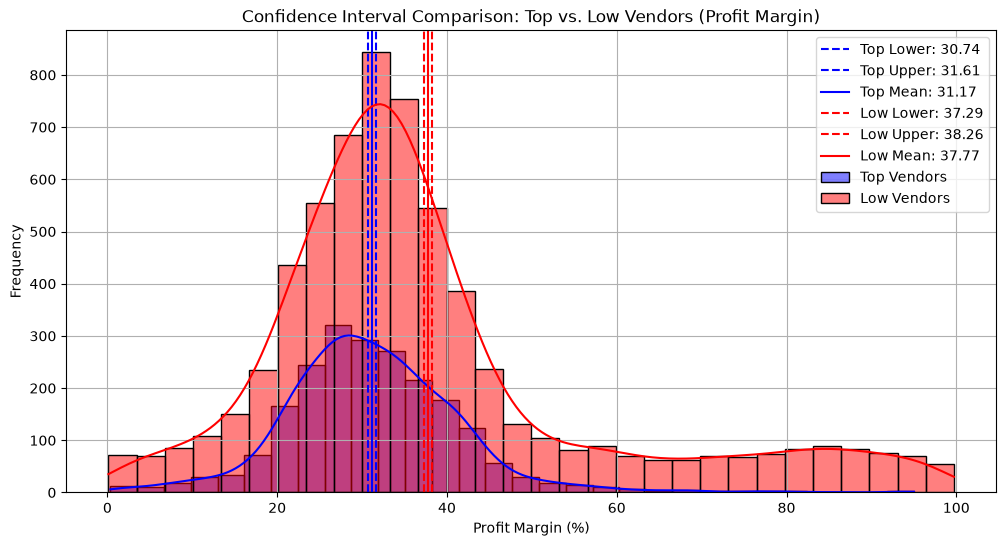

In [57]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

### Insights 
* The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
* This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
* For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
* For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved
distribution strategies.

### Is there a significant difference in profit margins between top-performing and low-performing vendors?
**Hypothesis:**\
Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.\
H, (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.